In [63]:
# --- AJOUT DES DÉCODEURS POUR ÉVITER LES ÉCRANS NOIRS ---
!pip install -q grad-cam pydicom nibabel pylibjpeg pylibjpeg-libjpeg pylibjpeg-openjpeg

import os, glob, numpy as np, pandas as pd, pydicom, cv2, torch, torch.nn as nn, nibabel as nib
from torch.utils.data import Dataset, DataLoader
from torchvision import models
import torchvision.transforms.functional as TF
from torchvision.transforms.functional import gaussian_blur
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import random

BASE_PATH = "/kaggle/input/rsna-2022-cervical-spine-fracture-detection"
TRAIN_IMAGES_DIR = os.path.join(BASE_PATH, "train_images")
TRAIN_CSV = os.path.join(BASE_PATH, "train.csv")
SEG_DIR = os.path.join(BASE_PATH, "segmentations")

# --- Fenêtrage osseux (unités Hounsfield) ---
def apply_bone_window(dcm, window_center=400, window_width=800):
    """Convertit les pixels en HU puis applique un fenêtrage osseux.
       Retourne une image normalisée [0,1]."""
    img = dcm.pixel_array.astype(np.float32)
    # Passage en HU avec RescaleSlope et Intercept
    slope = float(getattr(dcm, 'RescaleSlope', 1.0))
    intercept = float(getattr(dcm, 'RescaleIntercept', 0.0))
    img = slope * img + intercept  # maintenant en HU

    # Fenêtrage
    lower = window_center - window_width / 2
    upper = window_center + window_width / 2
    img = np.clip(img, lower, upper)
    img = (img - lower) / (upper - lower + 1e-6)
    return img


class RSNADatasetAug(Dataset):
    def __init__(self, df, image_dir, seg_dir=None, augment=False):
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.seg_dir = seg_dir
        self.augment = augment  # True uniquement pour l'entraînement

    def __len__(self): return len(self.df)

    def get_anatomical_centers(self, uid, num_slices):
        seg_path = os.path.join(self.seg_dir, f"{uid}.nii.gz")
        if os.path.exists(seg_path):
            try:
                data = nib.load(seg_path).get_fdata()
                centers = []
                for v_idx in range(1, 8):
                    z = np.where(data == v_idx)[2]
                    centers.append(int(np.median(z)) if len(z) > 0 else -1)
                return centers
            except: pass

        start = int(num_slices * 0.2)
        end = int(num_slices * 0.8)
        return np.linspace(start, end, 7).astype(int)

    def preprocess_slice(self, dcm):
        """Fenêtrage osseux + resize."""
        try:
            img = apply_bone_window(dcm)        # HU + fenêtrage
            img = cv2.resize(img, (224, 224))
            return img
        except:
            return np.zeros((224, 224), dtype=np.float32)

    def __getitem__(self, idx):
        uid = self.df.iloc[idx]['StudyInstanceUID']
        labels = self.df.iloc[idx][['C1','C2','C3','C4','C5','C6','C7']].values.astype(np.float32)
        path = os.path.join(self.image_dir, uid)
        slices_paths = sorted(glob.glob(os.path.join(path, "*.dcm")),
                              key=lambda x: int(os.path.basename(x).replace('.dcm', '')))
        num_slices = len(slices_paths)

        # Précharger les DICOM pour ne pas les relire 7 fois
        scans = []
        for sp in slices_paths:
            try:
                scans.append(pydicom.dcmread(sp))
            except:
                scans.append(None)

        vertebrae_stacks = []
        centers = self.get_anatomical_centers(uid, num_slices)
        for mid in centers:
            temp_stack = []
            if mid == -1:
                vertebrae_stacks.append(np.zeros((7, 224, 224), dtype=np.float32))
                continue
            for offset in range(-3, 4):
                idx_s = max(0, min(num_slices-1, mid + offset))
                if scans[idx_s] is not None:
                    s = self.preprocess_slice(scans[idx_s])
                else:
                    s = np.zeros((224, 224), dtype=np.float32)
                temp_stack.append(s)
            vertebrae_stacks.append(np.stack(temp_stack, axis=0))

        x = torch.tensor(np.array(vertebrae_stacks), dtype=torch.float32)  # (7,7,224,224)
        y = torch.tensor(labels, dtype=torch.float32)

        # Appliquer les augmentations si mode entraînement
        if self.augment:
            x = self._augment_stack(x)
        return x, y

    def _augment_stack(self, stack):
        """Applique rotation ±10°, translation ±10% et parfois un flou."""
        augmented = torch.zeros_like(stack)
        for v in range(7):  # chaque vertèbre indépendamment
            img_7c = stack[v]  # (7, 224, 224)
            # Rotation et translation aléatoires
            angle = random.uniform(-10, 10)
            translate = (random.uniform(-0.1, 0.1), random.uniform(-0.1, 0.1))
            img_aff = TF.affine(
                img_7c,
                angle=angle,
                translate=(int(translate[0]*224), int(translate[1]*224)),
                scale=1.0,
                shear=0.0,
                interpolation=TF.InterpolationMode.BILINEAR
            )
            # Flou gaussien avec 20% de chance
            if random.random() < 0.2:
                img_aff = gaussian_blur(img_aff.unsqueeze(0), kernel_size=3).squeeze(0)
            augmented[v] = img_aff
        return augmented


class MultiVertebraModelV2(nn.Module):
    """ResNet18 avec dropout (léger)"""
    def __init__(self, dropout=0.3):
        super().__init__()
        base = models.resnet18(weights='DEFAULT')
        base.conv1 = nn.Conv2d(7, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.encoder = nn.Sequential(*list(base.children())[:-1])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(512, 1)

    def forward(self, x):
        bs, nv, c, h, w = x.shape
        x = x.view(bs * nv, c, h, w)
        features = self.encoder(x).view(bs * nv, -1)
        features = self.dropout(features)
        logits = self.fc(features)
        return logits.view(bs, nv)


print("Cellule 1 OK : Décodeurs DICOM, fenêtrage osseux et augmentations prêts !")

Cellule 1 OK : Décodeurs DICOM, fenêtrage osseux et augmentations prêts !


Visualizzando: 1.2.826.0.1.3680043.32370.nii | Forma: (512, 512, 262)


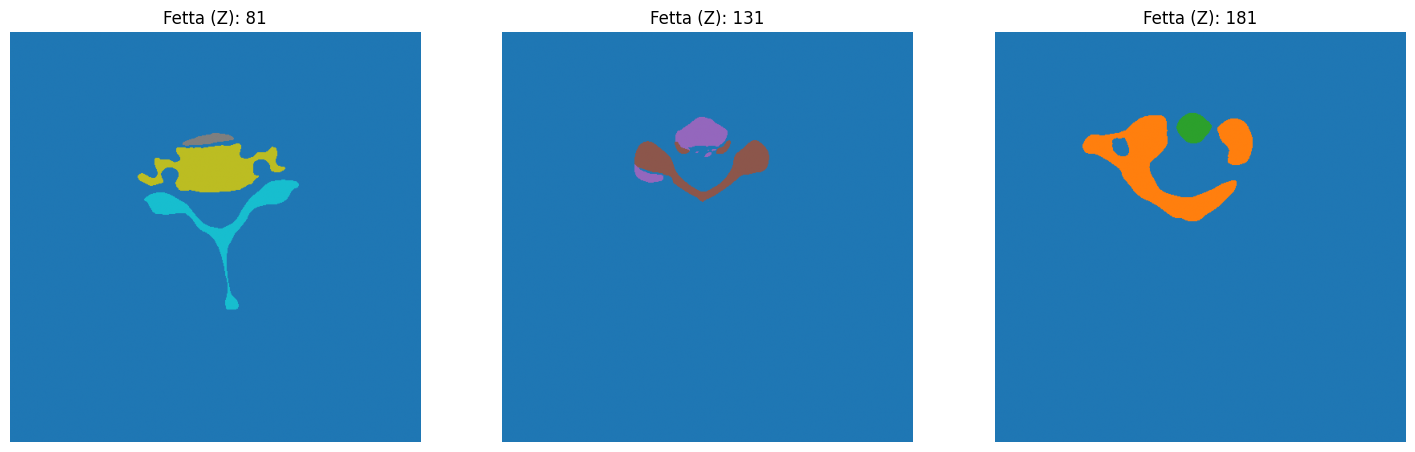

In [10]:
import nibabel as nib
import matplotlib.pyplot as plt
import random
import os
import numpy as np

def esplora_segmentazioni(seg_dir, num_exemple=1):
    # je cherche .nii ET .nii.gz pour être sûre
    seg_files = [f for f in os.listdir(seg_dir) if f.endswith(('.nii', '.nii.gz'))]
    
    if not seg_files:
        print(f"Errore: Nessun file trovato in {seg_dir}")
        return

    for _ in range(num_exemple):
        choix_fichier = random.choice(seg_files)  # casuale quindi cambia ogni volta
        path_complet = os.path.join(seg_dir, file_scelto)
        
        img = nib.load(path_complet)
        data = img.get_fdata()
        
        # Correction d'orientation fréquente pour NIfTI sur Kaggle
        data = np.transpose(data, (1, 0, 2))
        data = np.flip(data, axis=0)

        print(f"Visualizzando: {choix_fichier} | Forma: {data.shape}")
        
        z_mid = data.shape[2] // 2
        coupe = [max(0, z_mid - 50), z_mid, min(data.shape[2]-1, z_mid + 50)]
        
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        for i, f in enumerate(coupe):
            slice_data = data[:, :, f]
            #  j'utilise 'tab10' pour bien voir les 7 vertèbres (couleurs distinctes)
            im = axes[i].imshow(slice_data, cmap='tab10', vmin=0, vmax=7)
            axes[i].set_title(f"coupe (Z): {f}")
            axes[i].axis('off')
        
        plt.show()

#  SEG_DIR  doit etre bien défini
SEG_DIR = os.path.join(BASE_PATH, "segmentations")
esplora_segmentazioni(SEG_DIR, num_esempi=1)

In [64]:
def run_training():
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    print("Device:", DEVICE)

    df = pd.read_csv(TRAIN_CSV)
    seg_ids = [f.replace('.nii.gz', '').replace('.nii', '') for f in os.listdir(SEG_DIR)]

    #  segmentés + 200 aléatoires
    df_final = pd.concat([
        df[df['StudyInstanceUID'].isin(seg_ids)],
        df[~df['StudyInstanceUID'].isin(seg_ids)].sample(n=300, random_state=42)
    ]).sample(frac=1, random_state=42).reset_index(drop=True)

    train_df, val_df = train_test_split(df_final, test_size=0.15, random_state=42)

    # Datasets (augmentation uniquement à l'entraînement)
    train_dataset = RSNADatasetAug(train_df, TRAIN_IMAGES_DIR, SEG_DIR, augment=True)
    val_dataset   = RSNADatasetAug(val_df, TRAIN_IMAGES_DIR, SEG_DIR, augment=False)

    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2)
    val_loader   = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2)

    model = MultiVertebraModelV2(dropout=0.3).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

    pos_weight = torch.tensor([2.0]).to(DEVICE)   # poids modéré
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    EPOCHS = 15
    best_val_loss = float('inf')
    patience_counter = 0
    early_stop_patience = 2

    print(f"Entraînement lancé sur {len(df_final)} patients")
    print("-" * 60)

    for epoch in range(1, EPOCHS+1):
        # --- Entraînement ---
        model.train()
        train_loss_sum = 0
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss_sum += loss.item()
        avg_train_loss = train_loss_sum / len(train_loader)

        # --- Validation ---
        model.eval()
        val_loss_sum = 0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for v_images, v_labels in val_loader:
                v_images, v_labels = v_images.to(DEVICE), v_labels.to(DEVICE)
                v_outputs = model(v_images)
                loss = criterion(v_outputs, v_labels)
                val_loss_sum += loss.item()
                probs = torch.sigmoid(v_outputs).cpu().numpy()
                all_preds.append(probs.flatten())
                all_labels.append(v_labels.cpu().numpy().flatten())

        avg_val_loss = val_loss_sum / len(val_loader)
        all_preds = np.concatenate(all_preds)
        all_labels = np.concatenate(all_labels)
        preds_bin = (all_preds > 0.5).astype(int)

        # F1 macro
        f1 = f1_score(all_labels, preds_bin, average='macro') if all_labels.sum() > 0 else 0.0

        print(f"Epoch {epoch:2d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val F1: {f1:.4f}")

        # Scheduler + early stopping
        current_lr = optimizer.param_groups[0]['lr']
        scheduler.step(avg_val_loss)
        if optimizer.param_groups[0]['lr'] < current_lr:
            print(f"   📉 Learning rate réduit à {optimizer.param_groups[0]['lr']:.2e}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), "/kaggle/working/cervical_model_best.pth")
            patience_counter = 0
            print("   💾 Meilleur modèle sauvegardé")
        else:
            patience_counter += 1
            if patience_counter >= early_stop_patience:
                print("   ⏹️ Early stopping déclenché")
                break
        print("-" * 60)

    # Charger le meilleur modèle
    model.load_state_dict(torch.load("/kaggle/working/cervical_model_best.pth"))
    return model, val_df

model, val_df = run_training()

Device: cuda
Entraînement lancé sur 387 patients
------------------------------------------------------------
Epoch  1 | Train Loss: 0.5717 | Val Loss: 0.6220 | Val F1: 0.5285
   💾 Meilleur modèle sauvegardé
------------------------------------------------------------
Epoch  2 | Train Loss: 0.5056 | Val Loss: 0.4973 | Val F1: 0.5534
   💾 Meilleur modèle sauvegardé
------------------------------------------------------------
Epoch  3 | Train Loss: 0.4860 | Val Loss: 0.6110 | Val F1: 0.4980
------------------------------------------------------------
Epoch  4 | Train Loss: 0.4400 | Val Loss: 0.4953 | Val F1: 0.5895
   💾 Meilleur modèle sauvegardé
------------------------------------------------------------
Epoch  5 | Train Loss: 0.4012 | Val Loss: 0.5571 | Val F1: 0.5008
------------------------------------------------------------
Epoch  6 | Train Loss: 0.3672 | Val Loss: 0.5244 | Val F1: 0.5403
   ⏹️ Early stopping déclenché


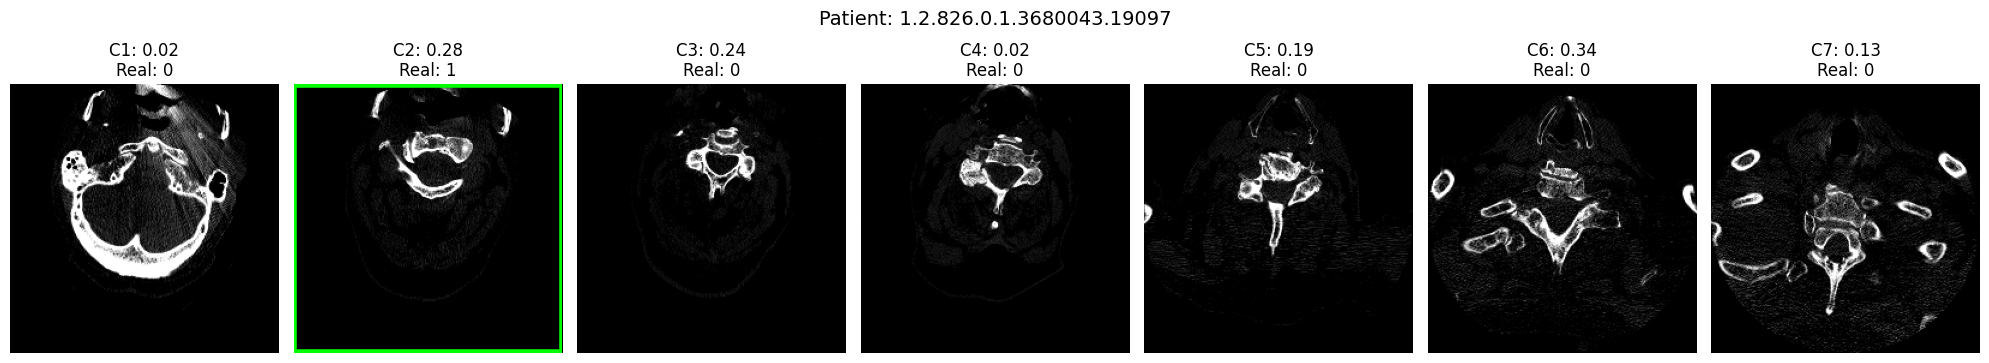

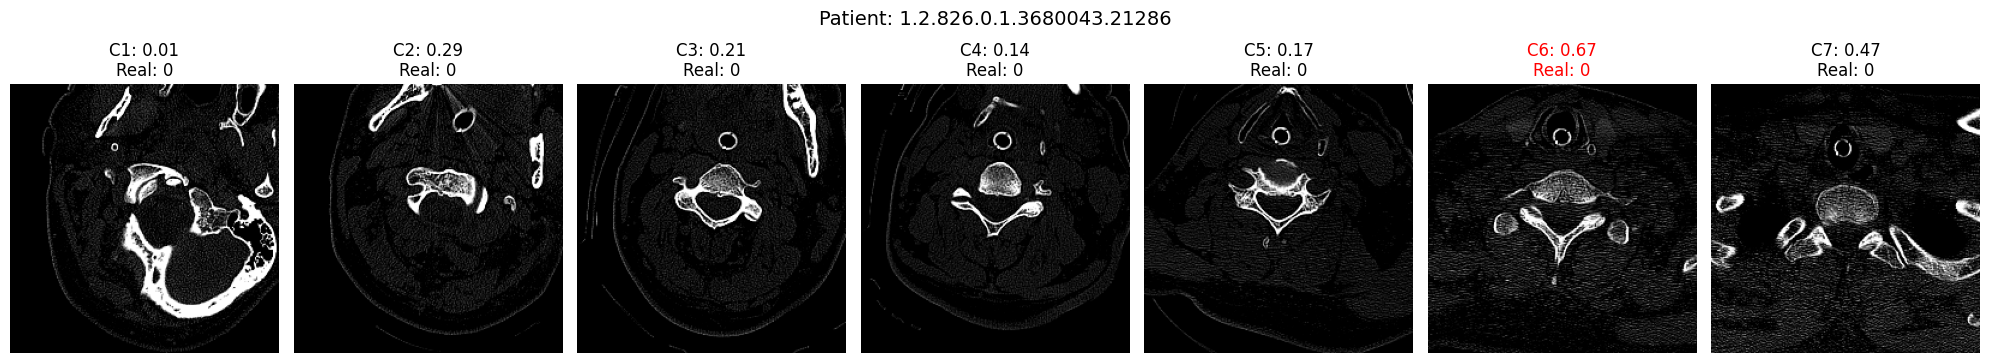

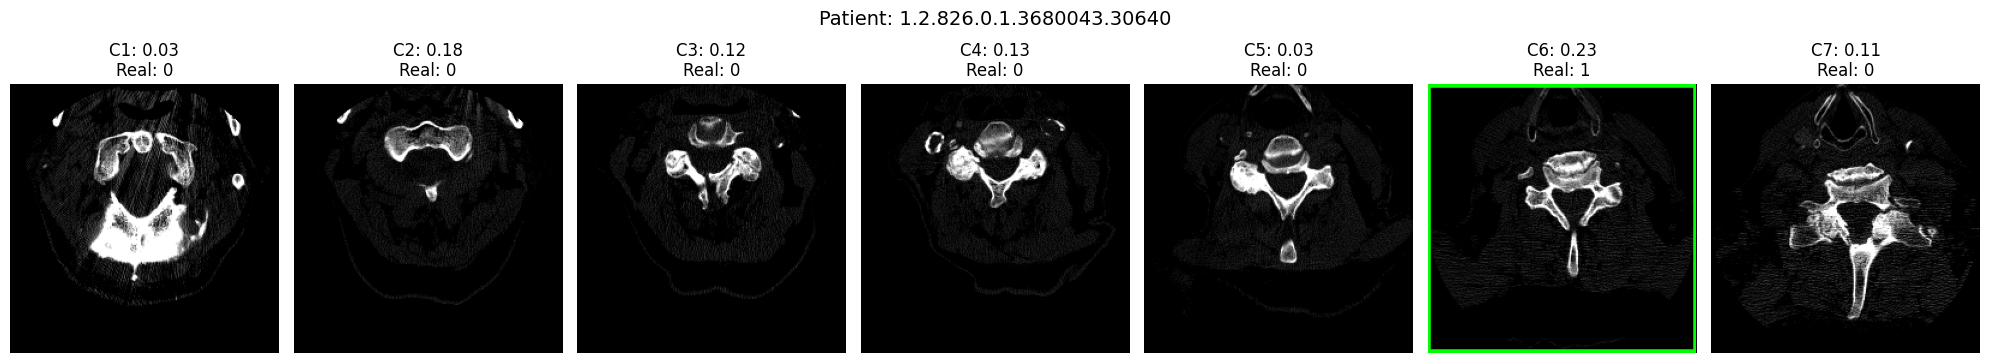

In [65]:
import matplotlib.pyplot as plt

def visualizza_predizioni(model, dataset, num_esempi=3):
    model.eval()
    device = next(model.parameters()).device

    for _ in range(num_esempi):
        idx = np.random.randint(0, len(dataset))
        inputs, labels = dataset[idx]
        uid = dataset.df.iloc[idx]['StudyInstanceUID']
        
        fig, axes = plt.subplots(1, 7, figsize=(20, 4))
        fig.suptitle(f"Patient: {uid}", fontsize=14)

        for v_idx in range(7):
            with torch.no_grad():
                prob = torch.sigmoid(model(inputs.unsqueeze(0).to(device)))[0, v_idx].item()
            
            milieu = inputs.shape[1] // 2
            img_base = inputs[v_idx, milieu].numpy()
            
            axes[v_idx].imshow(img_base, cmap='gray', vmin=0, vmax=1)
            color = 'red' if prob > 0.5 else 'black'
            axes[v_idx].set_title(f"C{v_idx+1}: {prob:.2f}\nReal: {int(labels[v_idx])}", color=color)
            axes[v_idx].axis('off')
            if labels[v_idx] == 1:
                rect = plt.Rectangle((0,0), 223, 223, linewidth=4, edgecolor='lime', facecolor='none')
                axes[v_idx].add_patch(rect)
        plt.tight_layout()
        plt.show()

# Affichage de quelques exemples du jeu de validation
val_dataset_viz = RSNADatasetAug(val_df.head(10), TRAIN_IMAGES_DIR, SEG_DIR, augment=False)
visualizza_predizioni(model, val_dataset_viz, num_esempi=3)